# Loan Default Prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Run if a new function added
from scripts.utilities import *
from scripts.features import *

## 1. Load and Process Data

In [3]:
# Load raw data
consumer_df, account_df, transaction_df = get_data()

# Filter unknown consumers
consumer_df, account_df, transaction_df = filter_unknown(consumer_df, account_df, transaction_df)

Data successfully loaded and processed.


In [4]:
# Define feature functions
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
    outflow_stats,
    # outflow_over_time,
    outflow_over_time_fix,
    balance_over_time
]

# Calculate features
feature_dataframes = execute_selected_features(selected_features, account_df, transaction_df)
final_features = merge_features(feature_dataframes)

# Merge with consumer data
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)


Feature Execution Plan:
- Total feature creation functions: 8
- Unchanged feature creation functions: 8 (using cached results)

No feature creation functions need to be executed.
- Using cached result for average_transaction_amount
- Using cached result for net_monthly_cash_flow
- Using cached result for average_account_balance
- Using cached result for time_based_average_transaction_amounts
- Using cached result for descriptive_stats_by_category
- Using cached result for outflow_stats
- Using cached result for outflow_over_time_fix
- Using cached result for balance_over_time

Total Created Features:  266


## 2 Split Data

In [5]:
# Split with validation set for hyperparameter tuning
train_df, _, test_df = split_data(ml_features, test_size=0.25)

# Define feature columns
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
all_feature_columns = [col for col in train_df.columns if col not in exclude_columns]

Training set size: 7591
No validation set created.
Test set size: 2531


## 3. Feature Selection

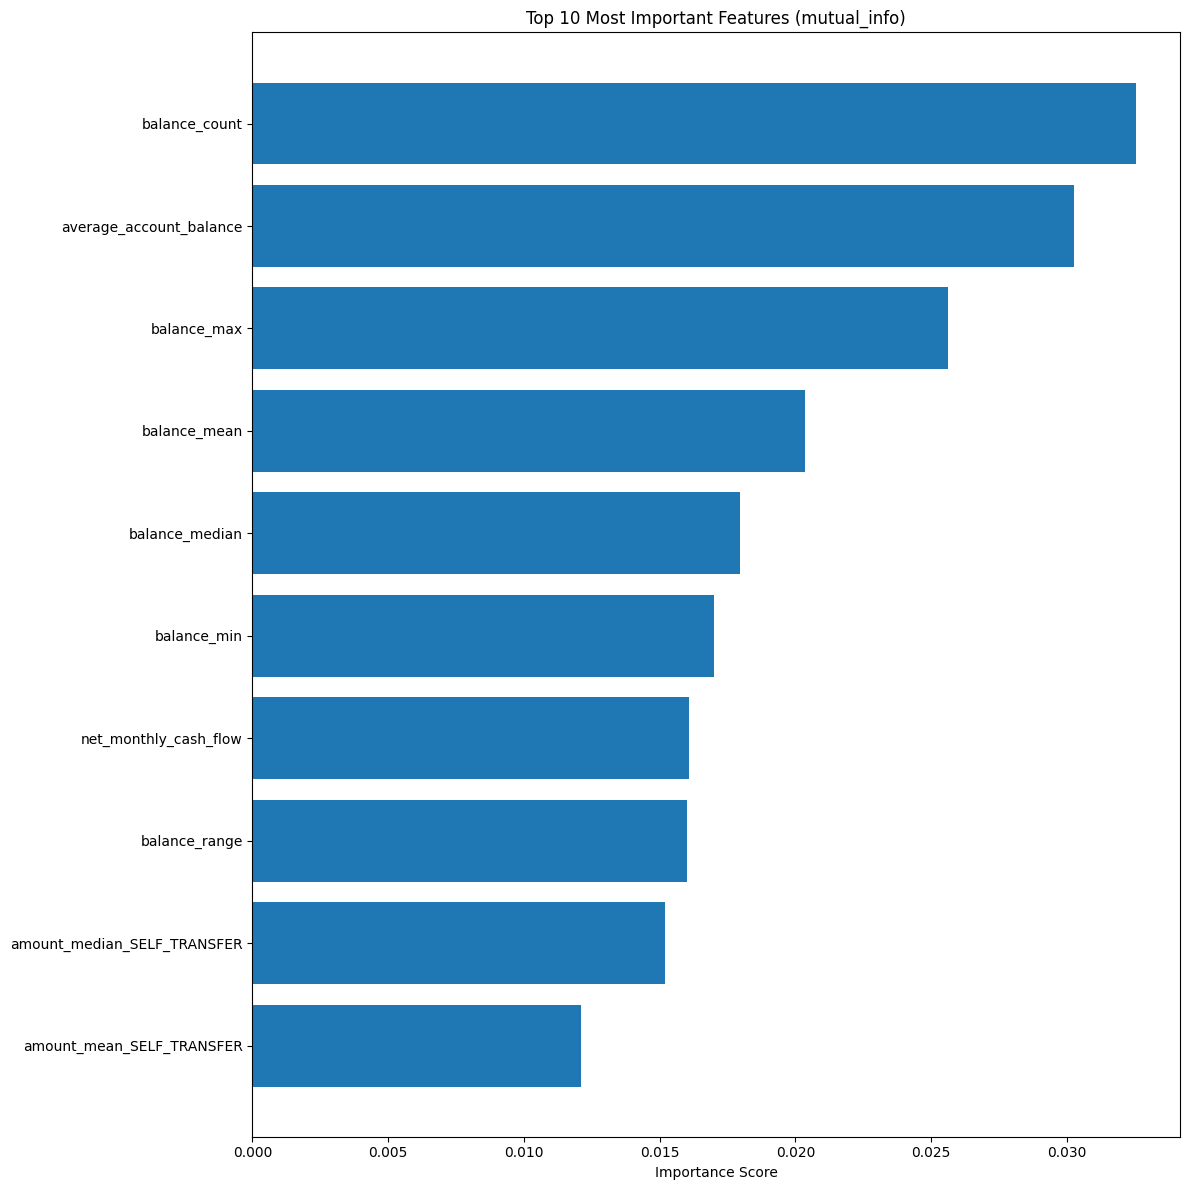

In [6]:
# Initialize the feature selector with your training DataFrame, feature columns, and any forced features.
fs = FeatureSelector(train_df, all_feature_columns)

# Run feature selection using the desired method(s)
# available --> ['mutual_info', 'random_forest', 'xgboost']
fs.run_feature_selection(methods=['mutual_info'], n_features=50)

# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Plot the importance scores for the selected method
fs.plot_feature_importance('mutual_info', top_n=10)

## 4. Model Performance

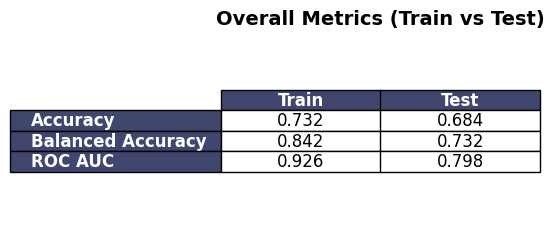

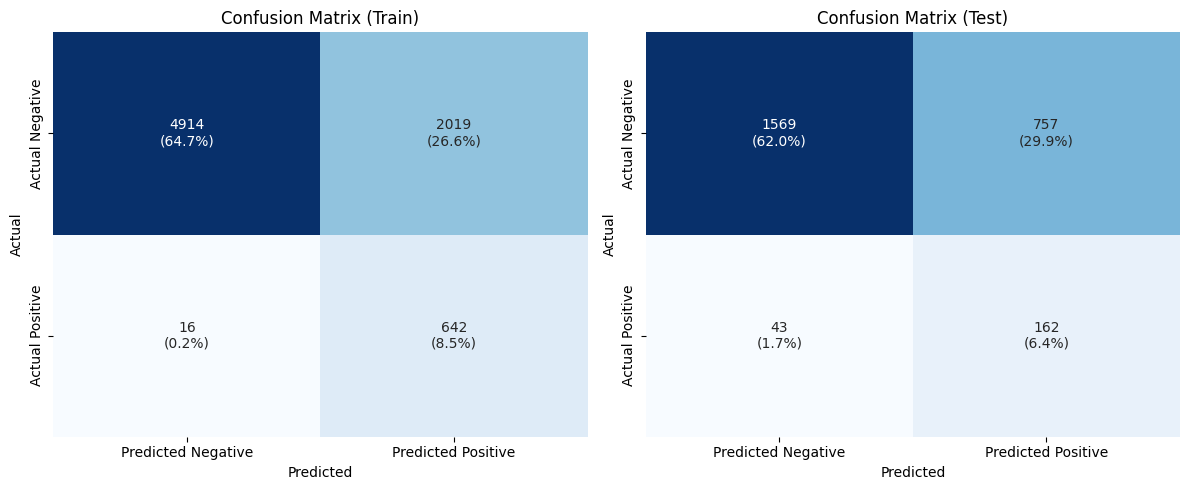

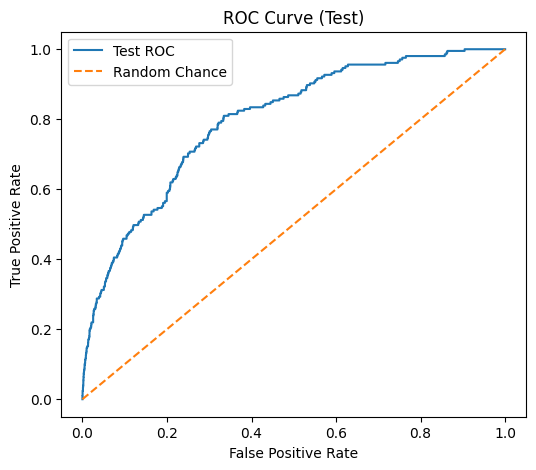

In [7]:
# Initialize and train model with all features
model, scaler = train_model(train_df, all_feature_columns, "xgboost")
results1 = predict_and_analyze_model(
    model, scaler, train_df, test_df, all_feature_columns,
    show_metrics=True,
    show_classification_report=False,
    show_confusion_matrix=True,
    show_roc_curve=True
)

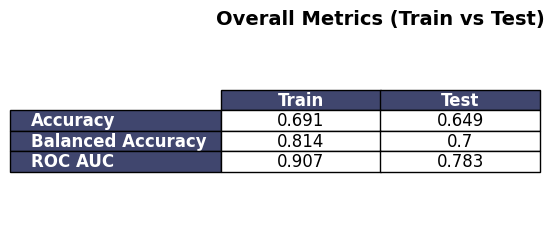

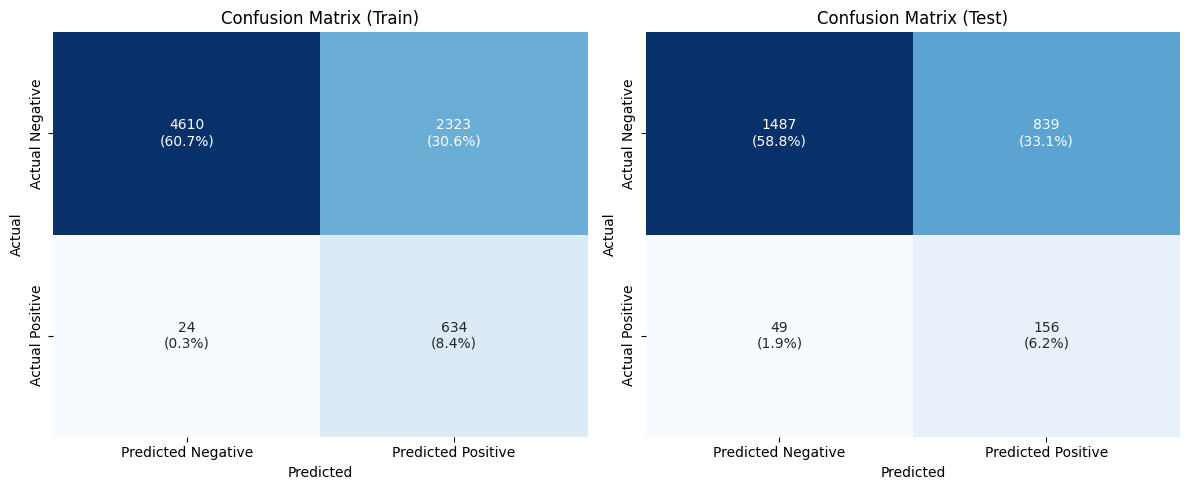

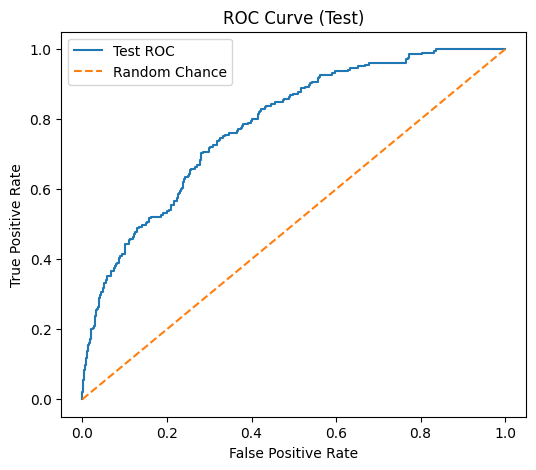

In [8]:
# Initialize and train model with best features
model, scaler = train_model(train_df, feature_columns, "xgboost")
results2 = predict_and_analyze_model(
    model, scaler, train_df, test_df, feature_columns,
    show_metrics=True,
    show_classification_report=False,
    show_confusion_matrix=True,
    show_roc_curve=True
)